In [1]:
import numpy as np
import os
import glob

# Define path to SHuBERT features
embedding_dir = 'output_embeddings'  

# Load all SHuBERT .npy feature files
embedding_files = sorted(glob.glob(os.path.join(embedding_dir, '*.npy')))
pose_embeddings = []

for file in embedding_files:
    data = np.load(file)  # shape: [L, T, 1024]

    # Use final layer only (or average across layers)
    final_layer = data[-1]  # shape: [T, 1024]

    # Extract last 14 dims as pose (per paper: from upper body keypoints)
    pose_only = final_layer[:, -14:]  # shape: [T, 14]

    # Average over time (to get 1 embedding per video)
    pose_avg = pose_only.mean(axis=0)  # shape: [14]
    pose_embeddings.append(pose_avg)

pose_embeddings = np.stack(pose_embeddings)  # shape: [N, 14]
print(f"Extracted {pose_embeddings.shape[0]} pose embeddings (14D each).")


Extracted 10 pose embeddings (14D each).


In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Choose number of clusters — same as in paper (10)
num_clusters = 2

kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_ids = kmeans.fit_predict(pose_embeddings)

print(f"Cluster distribution: {np.bincount(cluster_ids)}")


Cluster distribution: [4 6]


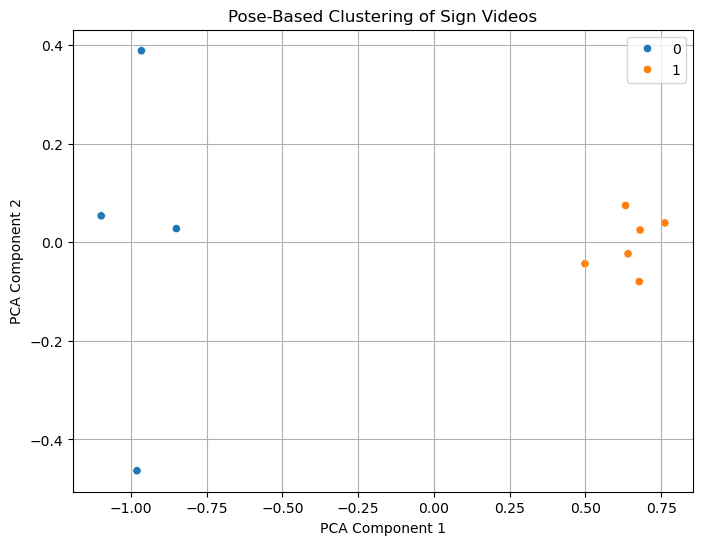

In [3]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
pose_2d = pca.fit_transform(pose_embeddings)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pose_2d[:, 0], y=pose_2d[:, 1], hue=cluster_ids, palette='tab10')
plt.title("Pose-Based Clustering of Sign Videos")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

In [4]:
import pandas as pd

cluster_df = pd.DataFrame({
    "video": [os.path.basename(f) for f in embedding_files],
    "cluster_id": cluster_ids
})

cluster_df.to_csv("shubert_pose_clusters.csv", index=False)
print("Saved cluster assignments to 'shubert_pose_clusters.csv'")


Saved cluster assignments to 'shubert_pose_clusters.csv'


In [7]:
import numpy as np

embedding_path = "output_embeddings/yaL8twcY9Lw-1.npy"
embedding = np.load(embedding_path)
print(f"Shape: {embedding.shape}")


Shape: (12, 189, 768)


In [6]:

import numpy as np

embedding_path = "output_embeddings/w_FKZNl_RdU-13.npy"
embedding = np.load(embedding_path)
print(f"Shape: {embedding.shape}")


Shape: (12, 63, 768)
